In [ ]:
!pip install roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [18]:
import zipfile
import os

# Altere para o nome exato do seu arquivo .zip
nome_do_zip = "scanner.yolov8.zip"

with zipfile.ZipFile(nome_do_zip, 'r') as zip_ref:
    zip_ref.extractall("dataset_gabarito")

print("Dataset extraído com sucesso na pasta 'dataset_gabarito'!")

yaml_conteudo = """
train: /content/dataset_gabarito/train/images
val: /content/dataset_gabarito/valid/images
test: /content/dataset_gabarito/test/images

nc: 1
names: ['ancora']  # <--- Atenção: coloque os nomes na ordem exata do Roboflow!
"""

with open("/content/dataset_gabarito/data.yaml", "w") as f:
    f.write(yaml_conteudo.strip())

print("✅ Arquivo data.yaml atualizado para 1 classes!")

Dataset extraído com sucesso na pasta 'dataset_gabarito'!
✅ Arquivo data.yaml atualizado para 1 classes!


In [19]:
from ultralytics import YOLO

# Inicializa o modelo nano do zero absoluto
model = YOLO("yolov8n.pt")

# Treino focado única e exclusivamente na classe 'ancora'
results = model.train(
    data="/content/dataset_gabarito/data.yaml",
    epochs=100,
    imgsz=640,
    device=0,
    workers=2,
    name="foco_ancoras_pequenas",

    # Hiperparâmetros agressivos para caixas minúsculas
    box=3.5,                     # Penalização pesadíssima para erro de tamanho/posição da caixa
    dfl=2.5,                     # Força foco cirúrgico nas bordas dos quadradinhos
    cls=1.0,

    # Augmentation controlado (Não queremos distorcer demais as âncoras)
    hsv_v=0.3,
    degrees=3.0,                # Rotação bem leve para não deformar o quadrado em losango
    translate=0.03,
    scale=0.03,
    close_mosaic=25              # Desativa o mosaico nas últimas 25 épocas para ver o papel limpo
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=3.5, cache=False, cfg=None, classes=None, close_mosaic=25, cls=1.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_gabarito/data.yaml, degrees=3.0, deterministic=True, device=0, dfl=2.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=foco_ancoras_pequenas, nbs=64, nms=False, opset=None, optimize=False, optimiz


📈 Exibindo: results.png


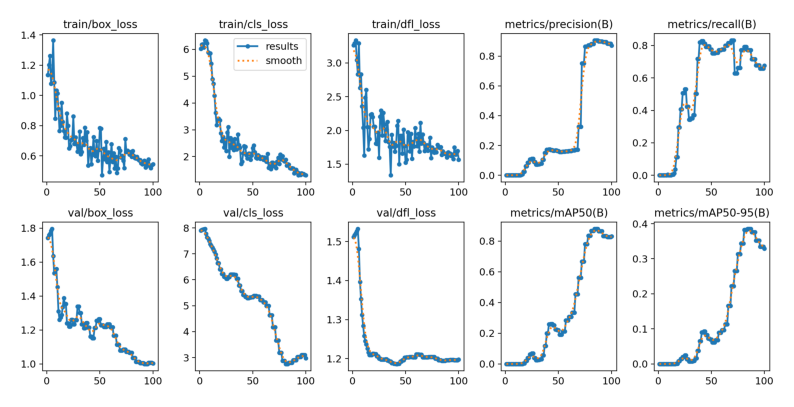


📈 Exibindo: confusion_matrix.png


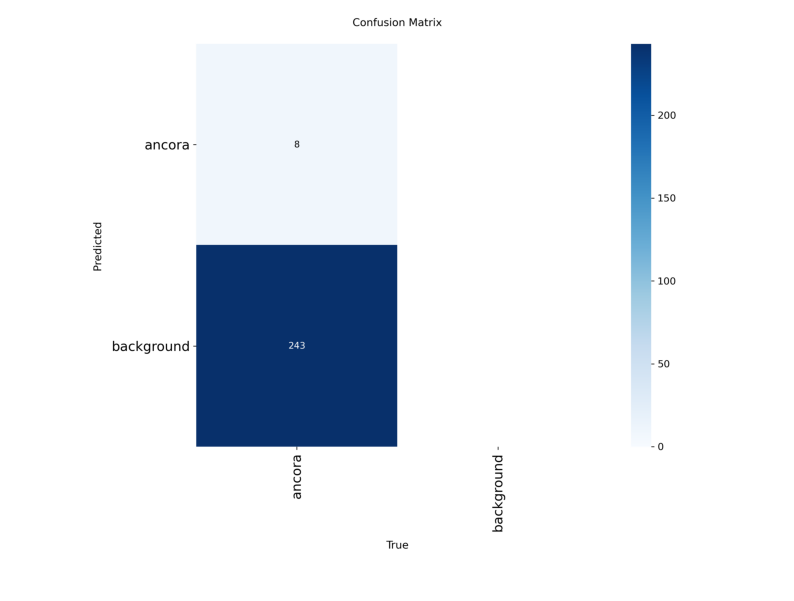

⚠️ O gráfico F1_curve.png não foi encontrado. Certifique-se de que o treino rodou por completo.
⚠️ O gráfico PR_curve.png não foi encontrado. Certifique-se de que o treino rodou por completo.


In [20]:
import os
import matplotlib.pyplot as plt
import cv2

# O caminho padrão onde o YOLOv8 salva todos os resultados do treino
caminho_resultados = "/content/runs/detect/foco_ancoras_pequenas/"

# Lista das imagens de métricas geradas automaticamente pela biblioteca
graficos_para_exibir = [
    "results.png",           # Gráficos de evolução das Perdas (Loss) e Precisão por época
    "confusion_matrix.png",   # Matriz de confusão para avaliar falsos positivos/negativos
    "F1_curve.png",           # Gráfico da Curva F1-Score em relação à confiança
    "PR_curve.png"            # Gráfico da Curva Precision-Recall (Precisão x Sensibilidade)
]

# Configura a exibição dos gráficos em sequência
for grafico in graficos_para_exibir:
    caminho_completo = os.path.join(caminho_resultados, grafico)

    if os.path.exists(caminho_completo):
        print(f"\n📈 Exibindo: {grafico}")
        img = cv2.imread(caminho_completo)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Corrige padrão de cores para o matplotlib

        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off') # Remove as bordas com eixos de pixel
        plt.show()
    else:
        print(f"⚠️ O gráfico {grafico} não foi encontrado. Certifique-se de que o treino rodou por completo.")

In [21]:
import pandas as pd
import os

# Aponta EXATAMENTE para a pasta que vimos na sua imagem
caminho_csv = "/content/runs/detect/foco_ancoras_pequenas/results.csv"

if os.path.exists(caminho_csv):
    df = pd.read_csv(caminho_csv)
    df.columns = df.columns.str.strip()
    ultima_epoca = df.iloc[-1]

    print("==================================================")
    print("      🎉 RESULTADOS REAIS: GABARITO OFICIAL       ")
    print("==================================================")
    print(f"🔹 Épocas treinadas nesta pasta: {len(df)}")
    print(f"🔹 Precisão (Precision):         {ultima_epoca['metrics/precision(B)']:.4f}")
    print(f"🔹 Sensibilidade (Recall):       {ultima_epoca['metrics/recall(B)']:.4f}")
    print(f"🔹 mAP50 Real:                   {ultima_epoca['metrics/mAP50(B)']:.4f}")
    print(f"🔹 mAP50-95 Real:                {ultima_epoca['metrics/mAP50-95(B)']:.4f}")
    print("==================================================")
else:
    print("⚠️ O arquivo results.csv não foi encontrado dentro de 'gabarito_oficial'.")
    print("Se o treino ainda estiver rodando, aguarde ele chegar ao fim para executar esta célula!")

      🎉 RESULTADOS REAIS: GABARITO OFICIAL       
🔹 Épocas treinadas nesta pasta: 100
🔹 Precisão (Precision):         0.8716
🔹 Sensibilidade (Recall):       0.6760
🔹 mAP50 Real:                   0.8315
🔹 mAP50-95 Real:                0.3288


In [17]:
import shutil
import os

# Apaga as pastas de treinos antigos para não haver confusão de memória
pastas_para_deletar = ['/content/runs/detect/treino_dataset_pequeno', '/content/dataset_gabarito', '/content/runs/detect/train-3', '/content/runs/detect/treinotreino_dataset_pequeno_duas_classes']

for pasta in pastas_para_deletar:
    if os.path.exists(pasta):
        shutil.rmtree(pasta)
        print(f"🧹 Pasta antiga deletada: {pasta}")

# Força a limpeza do cache de imagens do YOLO
cache_train = "/content/dataset_gabarito/train/labels.cache"
cache_val   = "/content/dataset_gabarito/valid/labels.cache"
if os.path.exists(cache_train): os.remove(cache_train)
if os.path.exists(cache_val): os.remove(cache_val)

print("✅ Ambiente limpo e pronto para um treino do zero absoluto!")

🧹 Pasta antiga deletada: /content/dataset_gabarito
✅ Ambiente limpo e pronto para um treino do zero absoluto!
